# Projet 7 - Implémentez un modèle de scoring
Utilisation d'un Kernel pour gagner du temps sur le préprocessing et le feature engineering du dataset.
## Imports

In [1]:
import numpy as np
import pandas as pd
import gc
import time
from contextlib import contextmanager

from sklearn.metrics import (roc_auc_score, roc_curve, auc, confusion_matrix,
                             classification_report, make_scorer,
                             precision_recall_curve, PrecisionRecallDisplay)
from sklearn.model_selection import (learning_curve, GridSearchCV,
                                     RandomizedSearchCV)
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import mlflow
from mlflow.tracking import MlflowClient
import shap
import joblib
from mlflow.models.signature import infer_signature

from sklearn import set_config
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
pd.set_option('display.max_row', 800)
pd.set_option("display.max_columns", None)
set_config(display="text")
sns.set_theme(style='whitegrid', palette='pastel')

## Accès aux données

In [3]:
chemin = "G:/Mon Drive/Yann Pham-Van - Data Scientist - OpenClassrooms/Projet7-Implémentez un modèle de scoring/data/"
mlflow_path = "file:///Users/Yann/Documents/Projet7-Implementez_un_modele_de_scoring/mlruns"
mlflow.set_tracking_uri(mlflow_path)

## Fonctions

In [4]:
@contextmanager
def timer(title):
    """Compteur de durée"""
    
    t0 = time.time()
    yield
    print("{} - fait en {:.0f}s".format(title, time.time() - t0))

def one_hot_encoder(df, nan_as_category = True):
    """One-hot encoding for categorical columns with get_dummies"""
    
    original_columns = list(df.columns)
    categorical_columns = [col for col in df.columns if df[col].dtype == 'object']
    df = pd.get_dummies(df, columns= categorical_columns, dummy_na= nan_as_category, dtype=int)
    new_columns = [c for c in df.columns if c not in original_columns]
    return df, new_columns

def application_train_test(num_rows = None, nan_as_category = False):
    """Preprocess application_train.csv and application_test.csv"""
    
    # Read data and merge
    df = pd.read_csv(chemin+"input/"+'application_train.csv', nrows= num_rows)
    test_df = pd.read_csv(chemin+"input/"+'application_test.csv', nrows= num_rows)
    print("Train samples: {}, test samples: {}".format(len(df), len(test_df)))
    # df = df.append(test_df).reset_index()
    df = pd.concat([df, test_df], ignore_index=True)
    # Optional: Remove 4 applications with XNA CODE_GENDER (train set)
    df = df[df['CODE_GENDER'] != 'XNA']
    
    # Categorical features with Binary encode (0 or 1; two categories)
    for bin_feature in ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
        df[bin_feature], uniques = pd.factorize(df[bin_feature])
    # Categorical features with One-Hot encode
    df, cat_cols = one_hot_encoder(df, nan_as_category)
    
    # NaN values for DAYS_EMPLOYED: 365.243 -> nan
    df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace= True)
    # Some simple new features (percentages)
    df['DAYS_EMPLOYED_PERC'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
    df['INCOME_CREDIT_PERC'] = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']
    df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
    df['ANNUITY_INCOME_PERC'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
    df['PAYMENT_RATE'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']
    del test_df
    gc.collect()
    return df

def bureau_and_balance(num_rows = None, nan_as_category = True):
    """Preprocess bureau.csv and bureau_balance.csv"""
    
    bureau = pd.read_csv(chemin+"input/"+'bureau.csv', nrows = num_rows)
    bb = pd.read_csv(chemin+"input/"+'bureau_balance.csv', nrows = num_rows)
    bb, bb_cat = one_hot_encoder(bb, nan_as_category)
    bureau, bureau_cat = one_hot_encoder(bureau, nan_as_category)
    
    # Bureau balance: Perform aggregations and merge with bureau.csv
    bb_aggregations = {'MONTHS_BALANCE': ['min', 'max', 'size']}
    for col in bb_cat:
        bb_aggregations[col] = ['mean']
    bb_agg = bb.groupby('SK_ID_BUREAU').agg(bb_aggregations)
    bb_agg.columns = pd.Index([e[0] + "_" + e[1].upper() for e in bb_agg.columns.tolist()])
    bureau = bureau.join(bb_agg, how='left', on='SK_ID_BUREAU')
    bureau.drop(['SK_ID_BUREAU'], axis=1, inplace= True)
    del bb, bb_agg
    gc.collect()
    
    # Bureau and bureau_balance numeric features
    num_aggregations = {
        'DAYS_CREDIT': ['min', 'max', 'mean', 'var'],
        'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
        'DAYS_CREDIT_UPDATE': ['mean'],
        'CREDIT_DAY_OVERDUE': ['max', 'mean'],
        'AMT_CREDIT_MAX_OVERDUE': ['mean'],
        'AMT_CREDIT_SUM': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_DEBT': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_OVERDUE': ['mean'],
        'AMT_CREDIT_SUM_LIMIT': ['mean', 'sum'],
        'AMT_ANNUITY': ['max', 'mean'],
        'CNT_CREDIT_PROLONG': ['sum'],
        'MONTHS_BALANCE_MIN': ['min'],
        'MONTHS_BALANCE_MAX': ['max'],
        'MONTHS_BALANCE_SIZE': ['mean', 'sum']
    }
    # Bureau and bureau_balance categorical features
    cat_aggregations = {}
    for cat in bureau_cat: cat_aggregations[cat] = ['mean']
    for cat in bb_cat: cat_aggregations[cat + "_MEAN"] = ['mean']
    
    bureau_agg = bureau.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
    bureau_agg.columns = pd.Index(['BURO_' + e[0] + "_" + e[1].upper() for e in bureau_agg.columns.tolist()])
    # Bureau: Active credits - using only numerical aggregations
    active = bureau[bureau['CREDIT_ACTIVE_Active'] == 1]
    active_agg = active.groupby('SK_ID_CURR').agg(num_aggregations)
    active_agg.columns = pd.Index(['ACTIVE_' + e[0] + "_" + e[1].upper() for e in active_agg.columns.tolist()])
    bureau_agg = bureau_agg.join(active_agg, how='left', on='SK_ID_CURR')
    del active, active_agg
    gc.collect()
    # Bureau: Closed credits - using only numerical aggregations
    closed = bureau[bureau['CREDIT_ACTIVE_Closed'] == 1]
    closed_agg = closed.groupby('SK_ID_CURR').agg(num_aggregations)
    closed_agg.columns = pd.Index(['CLOSED_' + e[0] + "_" + e[1].upper() for e in closed_agg.columns.tolist()])
    bureau_agg = bureau_agg.join(closed_agg, how='left', on='SK_ID_CURR')
    del closed, closed_agg, bureau
    gc.collect()
    return bureau_agg

def previous_applications(num_rows = None, nan_as_category = True):
    """Preprocess previous_applications.csv"""
    
    prev = pd.read_csv(chemin+"input/"+'previous_application.csv', nrows = num_rows)
    prev, cat_cols = one_hot_encoder(prev, nan_as_category= True)
    # Days 365.243 values -> nan
    prev['DAYS_FIRST_DRAWING'].replace(365243, np.nan, inplace= True)
    prev['DAYS_FIRST_DUE'].replace(365243, np.nan, inplace= True)
    prev['DAYS_LAST_DUE_1ST_VERSION'].replace(365243, np.nan, inplace= True)
    prev['DAYS_LAST_DUE'].replace(365243, np.nan, inplace= True)
    prev['DAYS_TERMINATION'].replace(365243, np.nan, inplace= True)
    # Add feature: value ask / value received percentage
    prev['APP_CREDIT_PERC'] = prev['AMT_APPLICATION'] / prev['AMT_CREDIT']
    # Previous applications numeric features
    num_aggregations = {
        'AMT_ANNUITY': ['min', 'max', 'mean'],
        'AMT_APPLICATION': ['min', 'max', 'mean'],
        'AMT_CREDIT': ['min', 'max', 'mean'],
        'APP_CREDIT_PERC': ['min', 'max', 'mean', 'var'],
        'AMT_DOWN_PAYMENT': ['min', 'max', 'mean'],
        'AMT_GOODS_PRICE': ['min', 'max', 'mean'],
        'HOUR_APPR_PROCESS_START': ['min', 'max', 'mean'],
        'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'],
        'DAYS_DECISION': ['min', 'max', 'mean'],
        'CNT_PAYMENT': ['mean', 'sum'],
    }
    # Previous applications categorical features
    cat_aggregations = {}
    for cat in cat_cols:
        cat_aggregations[cat] = ['mean']
    
    prev_agg = prev.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
    prev_agg.columns = pd.Index(['PREV_' + e[0] + "_" + e[1].upper() for e in prev_agg.columns.tolist()])
    # Previous Applications: Approved Applications - only numerical features
    approved = prev[prev['NAME_CONTRACT_STATUS_Approved'] == 1]
    approved_agg = approved.groupby('SK_ID_CURR').agg(num_aggregations)
    approved_agg.columns = pd.Index(['APPROVED_' + e[0] + "_" + e[1].upper() for e in approved_agg.columns.tolist()])
    prev_agg = prev_agg.join(approved_agg, how='left', on='SK_ID_CURR')
    # Previous Applications: Refused Applications - only numerical features
    refused = prev[prev['NAME_CONTRACT_STATUS_Refused'] == 1]
    refused_agg = refused.groupby('SK_ID_CURR').agg(num_aggregations)
    refused_agg.columns = pd.Index(['REFUSED_' + e[0] + "_" + e[1].upper() for e in refused_agg.columns.tolist()])
    prev_agg = prev_agg.join(refused_agg, how='left', on='SK_ID_CURR')
    del refused, refused_agg, approved, approved_agg, prev
    gc.collect()
    return prev_agg

def pos_cash(num_rows = None, nan_as_category = True):
    """Preprocess POS_CASH_balance.csv"""
    
    pos = pd.read_csv(chemin+"input/"+'POS_CASH_balance.csv', nrows = num_rows)
    pos, cat_cols = one_hot_encoder(pos, nan_as_category= True)
    # Features
    aggregations = {
        'MONTHS_BALANCE': ['max', 'mean', 'size'],
        'SK_DPD': ['max', 'mean'],
        'SK_DPD_DEF': ['max', 'mean']
    }
    for cat in cat_cols:
        aggregations[cat] = ['mean']
    
    pos_agg = pos.groupby('SK_ID_CURR').agg(aggregations)
    pos_agg.columns = pd.Index(['POS_' + e[0] + "_" + e[1].upper() for e in pos_agg.columns.tolist()])
    # Count pos cash accounts
    pos_agg['POS_COUNT'] = pos.groupby('SK_ID_CURR').size()
    del pos
    gc.collect()
    return pos_agg
    
def installments_payments(num_rows = None, nan_as_category = True):
    """Preprocess installments_payments.csv"""
    
    ins = pd.read_csv(chemin+"input/"+'installments_payments.csv', nrows = num_rows)
    ins, cat_cols = one_hot_encoder(ins, nan_as_category= True)
    # Percentage and difference paid in each installment (amount paid and installment value)
    ins['PAYMENT_PERC'] = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT']
    ins['PAYMENT_DIFF'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
    # Days past due and days before due (no negative values)
    ins['DPD'] = ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']
    ins['DBD'] = ins['DAYS_INSTALMENT'] - ins['DAYS_ENTRY_PAYMENT']
    ins['DPD'] = ins['DPD'].apply(lambda x: x if x > 0 else 0)
    ins['DBD'] = ins['DBD'].apply(lambda x: x if x > 0 else 0)
    # Features: Perform aggregations
    aggregations = {
        'NUM_INSTALMENT_VERSION': ['nunique'],
        'DPD': ['max', 'mean', 'sum'],
        'DBD': ['max', 'mean', 'sum'],
        'PAYMENT_PERC': ['max', 'mean', 'sum', 'var'],
        'PAYMENT_DIFF': ['max', 'mean', 'sum', 'var'],
        'AMT_INSTALMENT': ['max', 'mean', 'sum'],
        'AMT_PAYMENT': ['min', 'max', 'mean', 'sum'],
        'DAYS_ENTRY_PAYMENT': ['max', 'mean', 'sum']
    }
    for cat in cat_cols:
        aggregations[cat] = ['mean']
    ins_agg = ins.groupby('SK_ID_CURR').agg(aggregations)
    ins_agg.columns = pd.Index(['INSTAL_' + e[0] + "_" + e[1].upper() for e in ins_agg.columns.tolist()])
    # Count installments accounts
    ins_agg['INSTAL_COUNT'] = ins.groupby('SK_ID_CURR').size()
    del ins
    gc.collect()
    return ins_agg

def credit_card_balance(num_rows = None, nan_as_category = True):
    """Preprocess credit_card_balance.csv"""
    
    cc = pd.read_csv(chemin+"input/"+'credit_card_balance.csv', nrows = num_rows)
    cc, cat_cols = one_hot_encoder(cc, nan_as_category= True)
    # General aggregations
    cc.drop(['SK_ID_PREV'], axis= 1, inplace = True)
    cc_agg = cc.groupby('SK_ID_CURR').agg(['min', 'max', 'mean', 'sum', 'var'])
    cc_agg.columns = pd.Index(['CC_' + e[0] + "_" + e[1].upper() for e in cc_agg.columns.tolist()])
    # Count credit card lines
    cc_agg['CC_COUNT'] = cc.groupby('SK_ID_CURR').size()
    del cc
    gc.collect()
    return cc_agg

def main(debug = False):
    """Fonction principale appelant les fonctions précédentes"""
    num_rows = 10000 if debug else None
    df = application_train_test(num_rows)
    with timer("Process bureau and bureau_balance"):
        bureau = bureau_and_balance(num_rows)
        print("Bureau df shape:", bureau.shape)
        df = df.join(bureau, how='left', on='SK_ID_CURR')
        del bureau
        gc.collect()
    with timer("Process previous_applications"):
        prev = previous_applications(num_rows)
        print("Previous applications df shape:", prev.shape)
        df = df.join(prev, how='left', on='SK_ID_CURR')
        del prev
        gc.collect()
    with timer("Process POS-CASH balance"):
        pos = pos_cash(num_rows)
        print("Pos-cash balance df shape:", pos.shape)
        df = df.join(pos, how='left', on='SK_ID_CURR')
        del pos
        gc.collect()
    with timer("Process installments payments"):
        ins = installments_payments(num_rows)
        print("Installments payments df shape:", ins.shape)
        df = df.join(ins, how='left', on='SK_ID_CURR')
        del ins
        gc.collect()
    with timer("Process credit card balance"):
        cc = credit_card_balance(num_rows)
        print("Credit card balance df shape:", cc.shape)
        df = df.join(cc, how='left', on='SK_ID_CURR')
        del cc
        gc.collect()

    return df

## Lancement du kernel

In [5]:
with timer("______________________________________________________________________\nFull préprocessing & Feature engineering"):
    data = main()

Train samples: 307511, test samples: 48744
Bureau df shape: (305811, 116)
Process bureau and bureau_balance - fait en 13s
Previous applications df shape: (338857, 249)
Process previous_applications - fait en 14s
Pos-cash balance df shape: (337252, 18)
Process POS-CASH balance - fait en 7s
Installments payments df shape: (339587, 26)
Process installments payments - fait en 17s
Credit card balance df shape: (103558, 141)
Process credit card balance - fait en 9s
______________________________________________________________________
Full préprocessing & Feature engineering - fait en 63s


## Observations préliminaires

In [6]:
df = data.copy()

In [7]:
df.shape

(356251, 797)

In [8]:
df.head(5)

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,NAME_TYPE_SUITE_Children,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_INCOME_TYPE_Businessman,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Maternity leave,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Academic degree,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Civil marriage,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Unknown,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_Co-op apartment,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Accountants,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,WEEKDAY_APPR_PROCESS_START_FRIDAY,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Advertising,ORGANIZATION_TYPE_Agriculture,ORGANIZATION_TYPE_Bank,ORGANIZATION_TYPE_Business Entity Type 1,ORGANIZATION_TYPE_Business Entity Type 2,ORGANIZATION_

In [9]:
df.tail(5)

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,NAME_TYPE_SUITE_Children,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_INCOME_TYPE_Businessman,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Maternity leave,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Academic degree,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Civil marriage,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Unknown,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_Co-op apartment,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Accountants,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,WEEKDAY_APPR_PROCESS_START_FRIDAY,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Advertising,ORGANIZATION_TYPE_Agriculture,ORGANIZATION_TYPE_Bank,ORGANIZATION_TYPE_Business Entity Type 1,ORGANIZATION_TYPE_Business Entity Type 2,ORGANIZATION_

In [10]:
df.sample(5)

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,NAME_TYPE_SUITE_Children,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_INCOME_TYPE_Businessman,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Maternity leave,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Academic degree,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Civil marriage,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Unknown,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_Co-op apartment,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Accountants,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,WEEKDAY_APPR_PROCESS_START_FRIDAY,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Advertising,ORGANIZATION_TYPE_Agriculture,ORGANIZATION_TYPE_Bank,ORGANIZATION_TYPE_Business Entity Type 1,ORGANIZATION_TYPE_Business Entity Type 2,ORGANIZATION_

In [11]:
df.dtypes.value_counts()

float64    622
int32      133
int64       42
Name: count, dtype: int64

In [12]:
# Taux de manquants par colonnes
df.isna().mean().sort_values(ascending=False)

REFUSED_AMT_DOWN_PAYMENT_MIN                                             0.852343
REFUSED_RATE_DOWN_PAYMENT_MIN                                            0.852343
REFUSED_RATE_DOWN_PAYMENT_MEAN                                           0.852343
REFUSED_AMT_DOWN_PAYMENT_MEAN                                            0.852343
REFUSED_RATE_DOWN_PAYMENT_MAX                                            0.852343
REFUSED_AMT_DOWN_PAYMENT_MAX                                             0.852343
REFUSED_APP_CREDIT_PERC_VAR                                              0.836584
CC_AMT_PAYMENT_CURRENT_VAR                                               0.799012
CC_AMT_DRAWINGS_ATM_CURRENT_VAR                                          0.798760
CC_CNT_DRAWINGS_POS_CURRENT_VAR                                          0.798760
CC_AMT_DRAWINGS_POS_CURRENT_VAR                                          0.798760
CC_CNT_DRAWINGS_ATM_CURRENT_VAR                                          0.798760
CC_AMT_DRAWINGS_

In [13]:
# Valeurs dupliquées
df.duplicated().sum()

0

In [14]:
# Valeurs dupliquées sur colonnes hors Target
df.drop(columns='TARGET').duplicated().sum()

0

In [15]:
df.describe()

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,NAME_TYPE_SUITE_Children,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_INCOME_TYPE_Businessman,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Maternity leave,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Academic degree,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Civil marriage,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Unknown,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_Co-op apartment,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Accountants,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,WEEKDAY_APPR_PROCESS_START_FRIDAY,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Advertising,ORGANIZATION_TYPE_Agriculture,ORGANIZATION_TYPE_Bank,ORGANIZATION_TYPE_Business Entity Type 1,ORGANIZATION_TYPE_Business Entity Type 2,ORGANIZATION_

<Axes: ylabel='proportion'>

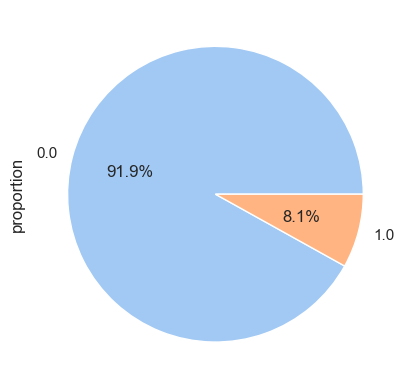

In [16]:
df['TARGET'].value_counts(normalize=True).plot(kind='pie', autopct='%.1f%%')

In [17]:
# Colonnes potentiellement inutiles, faute de variation des valeurs
df.nunique().sort_values()

PREV_NAME_CASH_LOAN_PURPOSE_nan_MEAN                                          1
PREV_NAME_CONTRACT_STATUS_nan_MEAN                                            1
PREV_CODE_REJECT_REASON_nan_MEAN                                              1
CC_NAME_CONTRACT_STATUS_Approved_MIN                                          1
POS_NAME_CONTRACT_STATUS_nan_MEAN                                             1
BURO_CREDIT_ACTIVE_nan_MEAN                                                   1
BURO_CREDIT_CURRENCY_nan_MEAN                                                 1
CC_NAME_CONTRACT_STATUS_Refused_MIN                                           1
BURO_CREDIT_TYPE_nan_MEAN                                                     1
BURO_STATUS_nan_MEAN_MEAN                                                     1
PREV_WEEKDAY_APPR_PROCESS_START_nan_MEAN                                      1
CC_NAME_CONTRACT_STATUS_nan_VAR                                               1
PREV_NAME_CONTRACT_TYPE_nan_MEAN        

## Préparation des données

### Fonctions de préparation

In [18]:
def reduction_taille_entier(df):
    """Transforme les entiers type 'int64' en type 'int32'."""
    
    df[df.columns[df.dtypes == 'int64']] = df[df.columns[df.dtypes == 'int64']].astype(dtype=np.int32, copy=False)
    return df

In [19]:
def suppression_colonnes_nan(df, taux_nan=0.8):
    """Suppression des variables avec trop de manquants"""
    
    df = df[df.columns[df.isna().mean() < taux_nan]]
        
    return df

In [20]:
def suppression_modalite_unique(df):
    """Suppression des variables avec une seule modalité"""
    
    df = df[df.columns[df.nunique() > 1]]
    return df

In [21]:
def separation_dataframe(df):
    """Séparation du dataframe en train et test correspondant aux dataframes du départ :
       application_train et application_test.
       Sauvegarde du dataframe_test pour usage ultérieur.
       Renvoi du dataframe_train pour la suite de la modélisation."""
    
    dataframe_train = df[df['TARGET'].notnull()]
    dataframe_test = df[df['TARGET'].isnull()]
    print("Dataframe avec target shape: {}, dataframe sans target shape: {}".format(dataframe_train.shape, dataframe_test.shape))
    dataframe_test.to_csv(chemin+"cleaned/"+"dataframe_test.csv", sep=',', index=False)
    del dataframe_test, df
    gc.collect()
    return dataframe_train

In [22]:
def dataframe_split(df):
    """Séparation du dataframe en 2 dataframes :
    - trainset
    - testset
    puis re-split de la target dans chacun des sets"""
    
    df = df.drop(columns={'SK_ID_CURR'})
    trainset , testset = train_test_split(df, test_size=0.3, random_state=39)
    X_train = trainset.drop(columns={'TARGET'})
    y_train = trainset['TARGET']
    X_test = testset.drop(columns={'TARGET'})
    y_test = testset['TARGET']
    print("Répartition de la target sur le jeu d'entraînement :")
    print(y_train.value_counts())
    print("Répartition de la target sur le jeu de test :")
    print(y_test.value_counts())
    del df, trainset, testset
    gc.collect()
    return X_train, y_train, X_test, y_test

In [23]:
def clean_infini(df):
    """Remplacement des valeurs 'infini' par des 'NaN'"""
    
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df

In [24]:
def preparation(df, taux_nan=0.8):
    """Fonction finalisant le pré-processing et renvoyant les 4 jeux d'entraînement et test"""
    
    with timer("Remplacement des valeurs 'int64' par des 'int32'"):
        df = reduction_taille_entier(df)
    with timer("Remplacement des valeurs 'infini' par des 'NaN'"):
        df = clean_infini(df)
    with timer("Suppression des variables avec trop de manquants"):
        df = suppression_colonnes_nan(df, taux_nan=0.8)
    with timer("Suppression des variables avec une seule modalité"):
        df = suppression_modalite_unique(df)
    with timer("Séparation du dataframe initial en dataframe_train et dataframe_test\npuis sauvegarde"):
        dataframe_train = separation_dataframe(df)
    with timer("Séparation du dataframe_train en trainset et testset"):
        X_train, y_train, X_test, y_test = dataframe_split(dataframe_train)
    
    
    return X_train, y_train, X_test, y_test

In [25]:
with timer("____________________________________________________\nPréparation finale des données"):
    X_train, y_train, X_test, y_test = preparation(df, taux_nan=0.8)

Remplacement des valeurs 'int64' par des 'int32' - fait en 0s
Remplacement des valeurs 'infini' par des 'NaN' - fait en 0s
Suppression des variables avec trop de manquants - fait en 1s
Suppression des variables avec une seule modalité - fait en 4s
Dataframe avec target shape: (307507, 763), dataframe sans target shape: (48744, 763)
Séparation du dataframe initial en dataframe_train et dataframe_test
puis sauvegarde - fait en 13s
Répartition de la target sur le jeu d'entraînement :
TARGET
0.0    197758
1.0     17496
Name: count, dtype: int64
Répartition de la target sur le jeu de test :
TARGET
0.0    84924
1.0     7329
Name: count, dtype: int64
Séparation du dataframe_train en trainset et testset - fait en 2s
____________________________________________________
Préparation finale des données - fait en 20s


## Fonctions d'évaluation

In [26]:
def confusion(y_test, y_pred):
    """Affiche la matrice de confusion"""
    
    mat = confusion_matrix(y_test, y_pred)
    mat = pd.DataFrame(mat)
    mat.columns = [f"pred_{i}" for i in mat.columns]
    mat.index = [f"test_{i}" for i in mat.index]
    plt.figure(figsize = (2, 2))
    plt.title('Matrice de confusion')
    sns.heatmap(mat, annot=True, cmap="Blues", fmt='0g', cbar=False)
    plt.show()
    return mat

In [27]:
def roc_auc(y_true, y_pred_proba):
    """Trace la courbe ROC et calcule le score ROC AUC"""
    
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    plt.figure(figsize=(10,10))
    plt.title('Receiver Operating Characteristic')
    plt.plot(false_positive_rate, true_positive_rate, color='red', label = 'AUC = %0.4f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.axis('tight')
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    return roc_auc

In [28]:
def fonction_metier(y_true, y_pred):
    """Création d'un score métier : minimisation du coût d’erreur de prédiction des FN et FP (pondération 10 contre 1)"""
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sm = (10*fn+fp)
    return sm

In [29]:
def evaluation(model):
    """Evaluation d'un modèle affichant :
        - la matrice de confusion
        - le score métier
        - la courbe ROC avec le score ROC AUC"""
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:,1]
    
    confusion(y_test, y_pred)
    score_metier = fonction_metier(y_test, y_pred)
    print("\nScore métier =", score_metier, "\n(Le meilleur est le plus bas)")
    print("\n________________\nRapport de classification")
    print(classification_report(y_test, y_pred))
    roc_auc(y_test, y_pred_proba)
    return score_metier

## Modélisation
### Dummy classifier

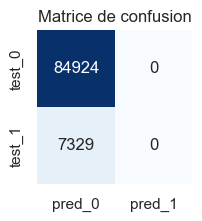


Score métier = 73290 
(Le meilleur est le plus bas)

________________
Rapport de classification
              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96     84924
         1.0       0.00      0.00      0.00      7329

    accuracy                           0.92     92253
   macro avg       0.46      0.50      0.48     92253
weighted avg       0.85      0.92      0.88     92253



Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


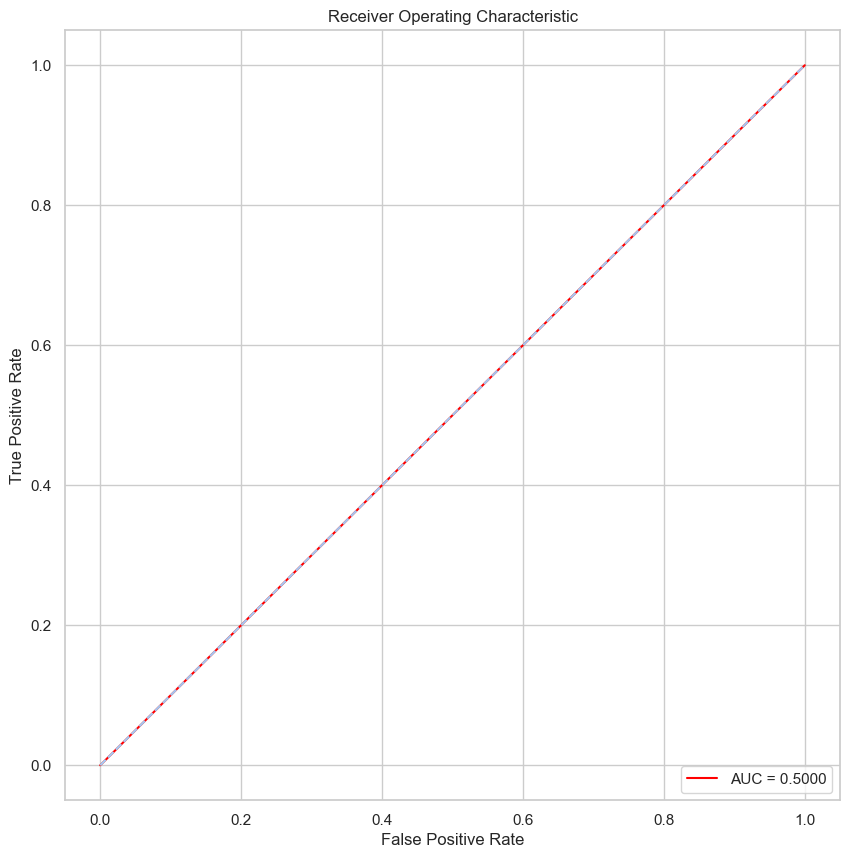

73290

In [30]:
estimator = DummyClassifier(strategy='most_frequent')
evaluation(estimator)

### Modèles à tester

In [31]:
preprocessor = make_pipeline(SimpleImputer(missing_values = np.nan, strategy='median'),
                             SelectKBest(f_classif, k='all'))

In [32]:
RandomForest = make_pipeline(preprocessor,
                             RandomForestClassifier(class_weight='balanced',
                                                    random_state=39,
                                                    n_jobs=-1))

LogisticRegression = make_pipeline(preprocessor,
                                   StandardScaler(),
                                   LogisticRegression(class_weight='balanced',
                                                      random_state=39,
                                                      n_jobs=-1))

XGBoost = make_pipeline(preprocessor,
                        XGBClassifier(scale_pos_weight=(y_train.value_counts()[0]/y_train.value_counts()[1]),
                                      random_state=39,
                                      n_jobs=-1))

LightGBM = make_pipeline(preprocessor,
                         LGBMClassifier(class_weight='balanced',
                                        random_state=39,
                                        n_jobs=-1))

In [33]:
dict_of_models = {'RandomForest': RandomForest,
                  'LogisticRegression': LogisticRegression,
                  'XGBoost': XGBoost,
                  'LightGBM': LightGBM
                 }

----------------------------------------------------------------------

Modèle : RandomForest


C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [468 718 723 742] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


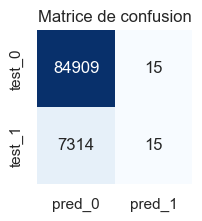


Score métier = 73155 
(Le meilleur est le plus bas)

________________
Rapport de classification
              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96     84924
         1.0       0.50      0.00      0.00      7329

    accuracy                           0.92     92253
   macro avg       0.71      0.50      0.48     92253
weighted avg       0.89      0.92      0.88     92253



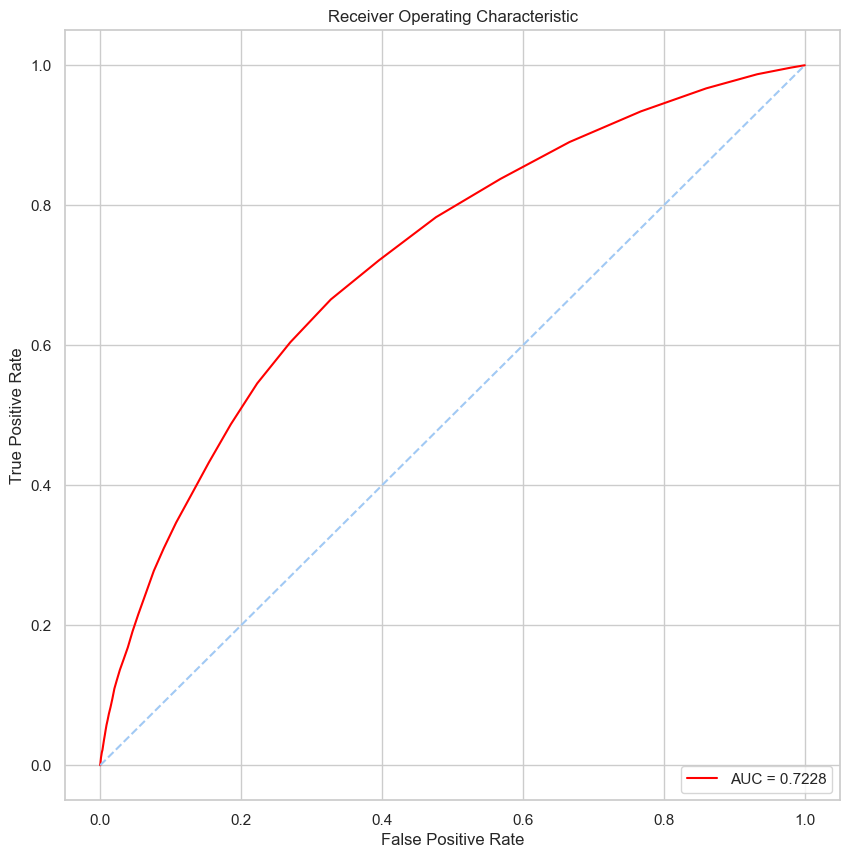

Modèle - fit, predict, scores - fait en 47s
----------------------------------------------------------------------

Modèle : LogisticRegression


C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [468 718 723 742] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


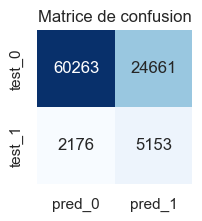


Score métier = 46421 
(Le meilleur est le plus bas)

________________
Rapport de classification
              precision    recall  f1-score   support

         0.0       0.97      0.71      0.82     84924
         1.0       0.17      0.70      0.28      7329

    accuracy                           0.71     92253
   macro avg       0.57      0.71      0.55     92253
weighted avg       0.90      0.71      0.77     92253



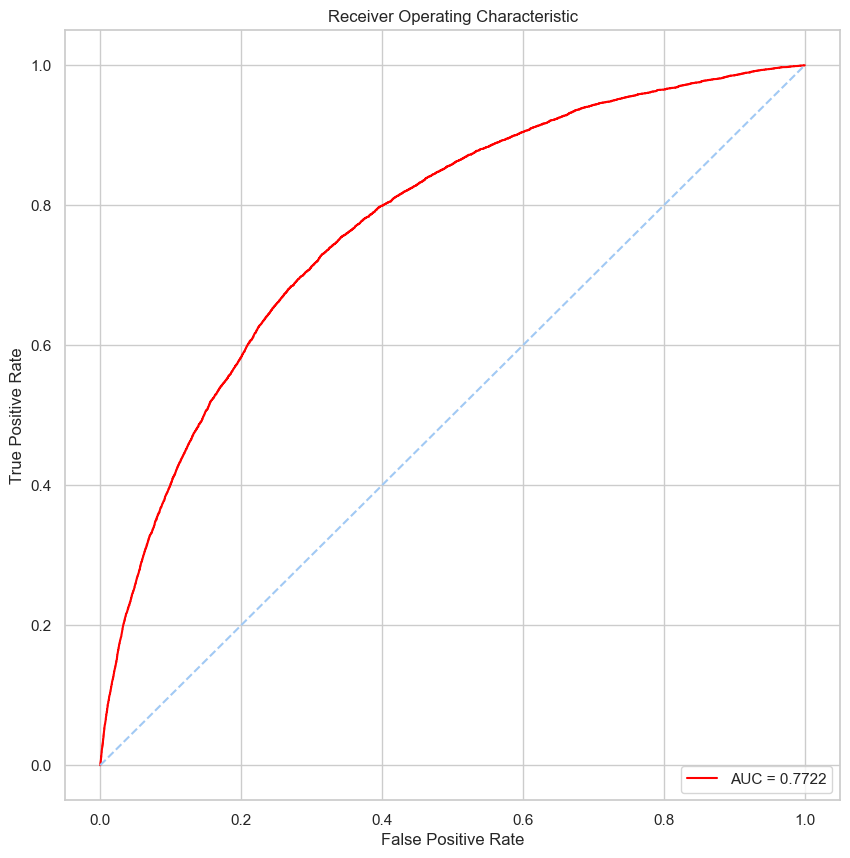

Modèle - fit, predict, scores - fait en 31s
----------------------------------------------------------------------

Modèle : XGBoost


C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [468 718 723 742] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


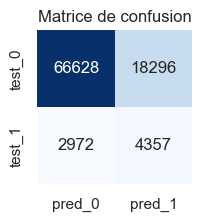


Score métier = 48016 
(Le meilleur est le plus bas)

________________
Rapport de classification
              precision    recall  f1-score   support

         0.0       0.96      0.78      0.86     84924
         1.0       0.19      0.59      0.29      7329

    accuracy                           0.77     92253
   macro avg       0.57      0.69      0.58     92253
weighted avg       0.90      0.77      0.82     92253



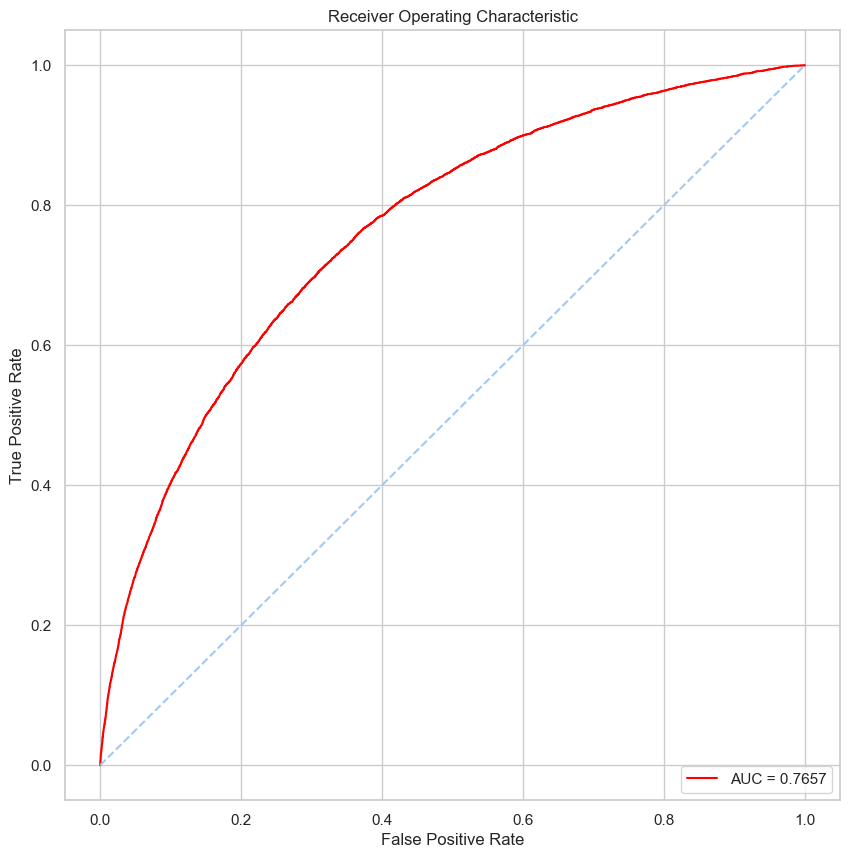

Modèle - fit, predict, scores - fait en 98s
----------------------------------------------------------------------

Modèle : LightGBM


C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [468 718 723 742] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


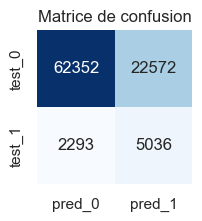


Score métier = 45502 
(Le meilleur est le plus bas)

________________
Rapport de classification
              precision    recall  f1-score   support

         0.0       0.96      0.73      0.83     84924
         1.0       0.18      0.69      0.29      7329

    accuracy                           0.73     92253
   macro avg       0.57      0.71      0.56     92253
weighted avg       0.90      0.73      0.79     92253



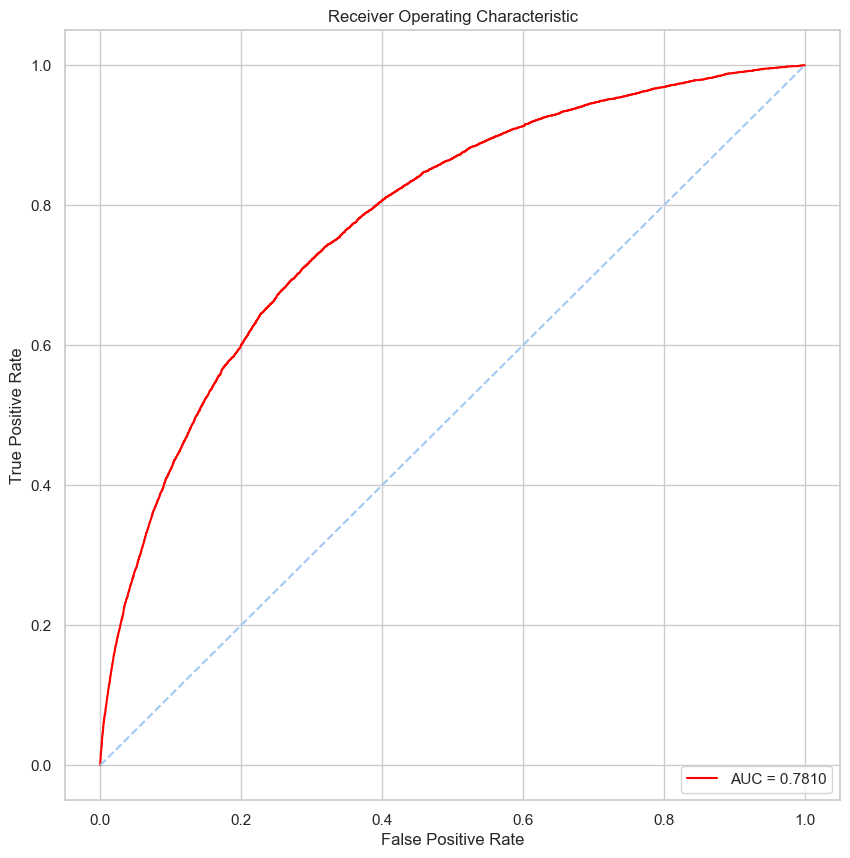

Modèle - fit, predict, scores - fait en 28s


In [34]:
for name, model in dict_of_models.items():
    with timer("Modèle - fit, predict, scores"):
        print('-'*70)
        print('\nModèle :', name)
        evaluation(model)

Actuellement, les **meilleurs résultats** sont apportés par **LightGBM**, en termes de scores métier et AUC et aussi en temps de calculs.

Mais, il est possible d'améliorer tous les modèles.
## Optimisation des modèles par validation croisée

In [35]:
hyper_params_modeles = {'RandomForest': {'randomforestclassifier__n_estimators': [10, 200],
                                         'randomforestclassifier__criterion': ['gini', 'entropy'],
                                         'randomforestclassifier__max_depth': [3, 6]},
                        'LogisticRegression': {'logisticregression__solver': ['newton-cholesky', 'sag']},
                        'XGBoost': {'xgbclassifier__max_depth': [2, 6],
                                    'xgbclassifier__subsample': [0.1, 1],
                                    'xgbclassifier__colsample_bytree': [0.1, 1]},
                        'LightGBM': {'lgbmclassifier__n_estimators': [10, 200],
                                     'lgbmclassifier__max_depth': [2, 30],
                                     'lgbmclassifier__colsample_bytree': [0.1, 1]}
                       }

Transformation de la fonction métier en score métier à utiliser comme scoring de la validation croisée :

In [36]:
score_metier = make_scorer(fonction_metier, greater_is_better=False)

In [37]:
def optimisation(model, name):
    grid = GridSearchCV(model, hyper_params_modeles[name], scoring=score_metier, cv=3, n_jobs=-1, return_train_score=True)
    grid.fit(X_train,y_train)
    y_pred_proba_train = grid.best_estimator_.predict_proba(X_train)[:,1]
    y_pred_proba_test = grid.best_estimator_.predict_proba(X_test)[:,1]
    y_pred = grid.best_estimator_.predict(X_test)
    
    
    print("\nRésultats de la validation croisée :")    
    for mean_train_train, std_train_train, params_train_train, mean_test_train, std_test_train, params_test_train in zip(
        grid.cv_results_['mean_train_score'], # score moyen sur train de validation
        grid.cv_results_['std_train_score'],  # écart-type du score sur train de validation
        grid.cv_results_['params'],           # valeur de l'hyperparamètre
        grid.cv_results_['mean_test_score'], # score moyen sur fold de test de validation
        grid.cv_results_['std_test_score'],  # écart-type du score sur fold de test de validation
        grid.cv_results_['params']           # valeur de l'hyperparamètre
        ):
        print("Score métier moyen sur les folds du jeu d'entraînement dans la CV = {:.2f} (+/-{:.02f}) pour {}".format(
            mean_train_train,
            std_train_train*2,
            params_train_train
        ))
        print("Score métier moyen sur les folds du jeu de test dans la CV = {:.2f} (+/-{:.02f}) pour {}".format(
            mean_test_train,
            std_test_train*2,
            params_test_train
        ))
    
    print('\nMeilleurs hyper-paramètres :', grid.best_params_)
    matrice_confusion = confusion(y_test, y_pred)
    score_metier_test = fonction_metier(y_test, y_pred)
    print("\nScore métier sur le jeu de test avec les meilleurs hyper-paramètres :")
    print(score_metier_test)
    print(classification_report(y_test, y_pred))
    print("\nAUC sur le jeu d'entraînement complet")
    roc_auc(y_train, y_pred_proba_train)
    print("\nAUC sur le jeu de test")
    roc_auc(y_test, y_pred_proba_test)

------------------------------------------------------------------------------------------
RandomForest


C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [468 718 723 742] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Résultats de la validation croisée :
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -86383.33 (+/-1284.66) pour {'randomforestclassifier__criterion': 'gini', 'randomforestclassifier__max_depth': 3, 'randomforestclassifier__n_estimators': 10}
Score métier moyen sur les folds du jeu de test dans la CV = -43969.00 (+/-621.11) pour {'randomforestclassifier__criterion': 'gini', 'randomforestclassifier__max_depth': 3, 'randomforestclassifier__n_estimators': 10}
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -82540.00 (+/-1002.61) pour {'randomforestclassifier__criterion': 'gini', 'randomforestclassifier__max_depth': 3, 'randomforestclassifier__n_estimators': 200}
Score métier moyen sur les folds du jeu de test dans la CV = -41970.00 (+/-151.97) pour {'randomforestclassifier__criterion': 'gini', 'randomforestclassifier__max_depth': 3, 'randomforestclassifier__n_estimators': 200}
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -790

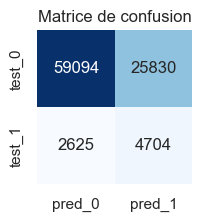


Score métier sur le jeu de test avec les meilleurs hyper-paramètres :
52080
              precision    recall  f1-score   support

         0.0       0.96      0.70      0.81     84924
         1.0       0.15      0.64      0.25      7329

    accuracy                           0.69     92253
   macro avg       0.56      0.67      0.53     92253
weighted avg       0.89      0.69      0.76     92253


AUC sur le jeu d'entraînement complet


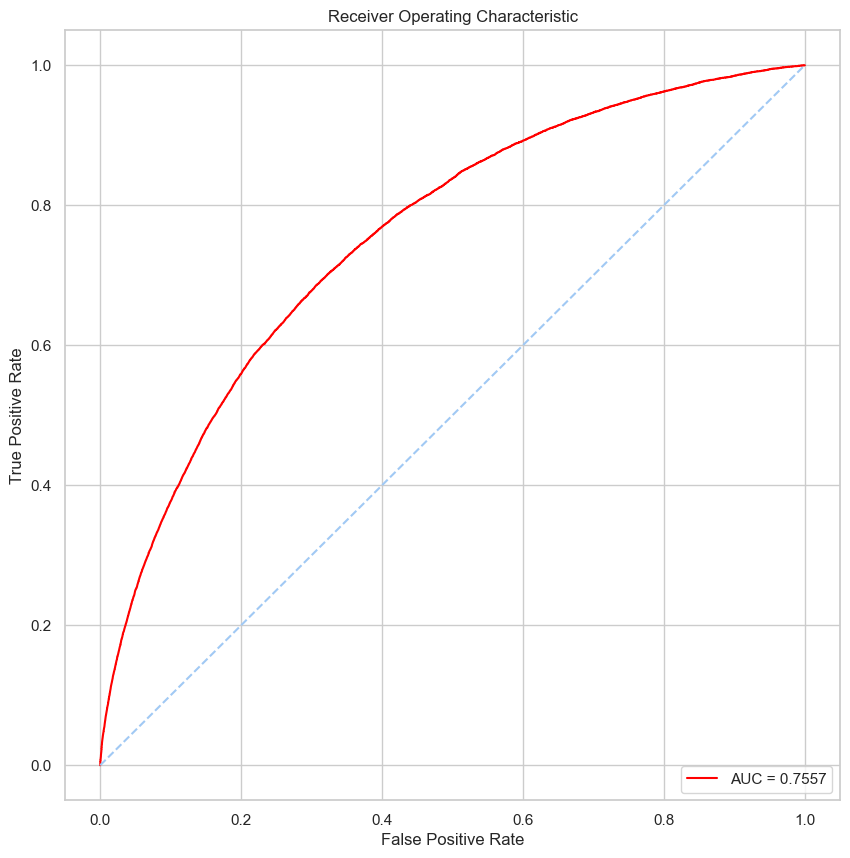


AUC sur le jeu de test


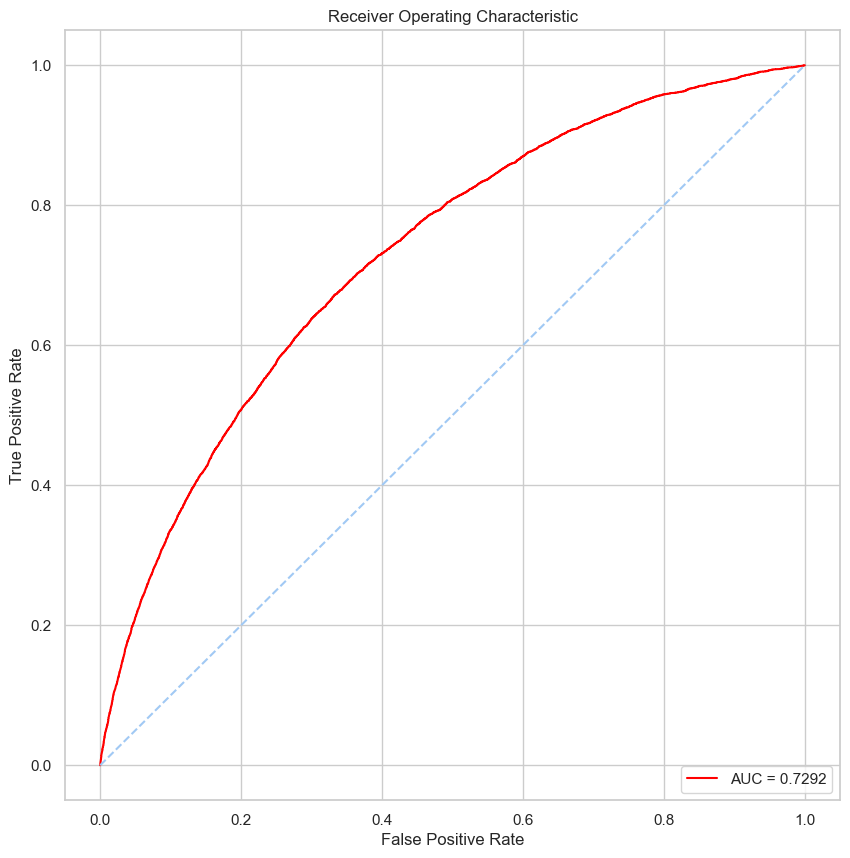

------------------------------------------------------------------------------------------
LogisticRegression


C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [468 718 723 742] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Résultats de la validation croisée :
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -70926.33 (+/-899.44) pour {'logisticregression__solver': 'newton-cholesky'}
Score métier moyen sur les folds du jeu de test dans la CV = -37006.00 (+/-797.82) pour {'logisticregression__solver': 'newton-cholesky'}
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -71705.67 (+/-1108.90) pour {'logisticregression__solver': 'sag'}
Score métier moyen sur les folds du jeu de test dans la CV = -37077.00 (+/-744.07) pour {'logisticregression__solver': 'sag'}

Meilleurs hyper-paramètres : {'logisticregression__solver': 'newton-cholesky'}


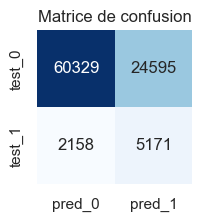


Score métier sur le jeu de test avec les meilleurs hyper-paramètres :
46175
              precision    recall  f1-score   support

         0.0       0.97      0.71      0.82     84924
         1.0       0.17      0.71      0.28      7329

    accuracy                           0.71     92253
   macro avg       0.57      0.71      0.55     92253
weighted avg       0.90      0.71      0.78     92253


AUC sur le jeu d'entraînement complet


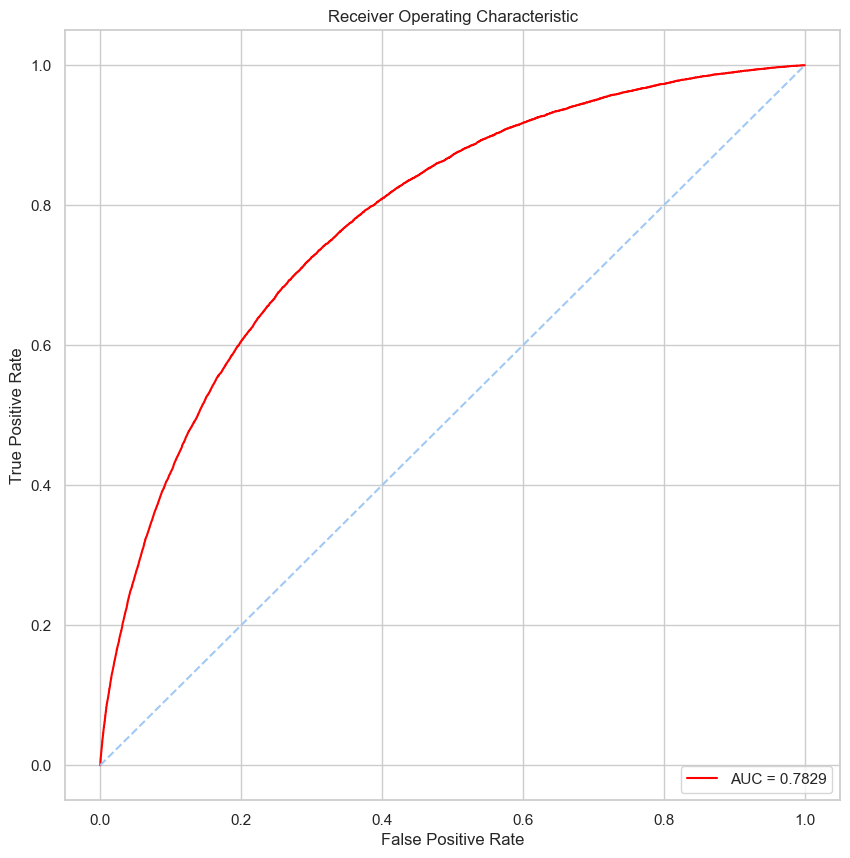


AUC sur le jeu de test


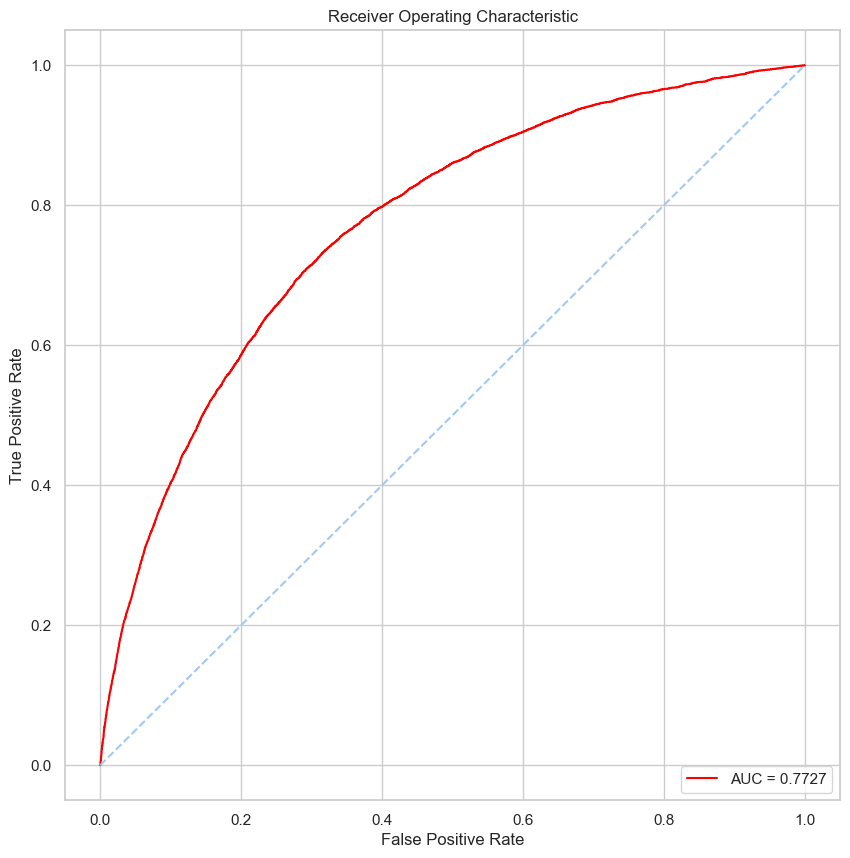

------------------------------------------------------------------------------------------
XGBoost


C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [468 718 723 742] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Résultats de la validation croisée :
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -74413.67 (+/-896.63) pour {'xgbclassifier__colsample_bytree': 0.1, 'xgbclassifier__max_depth': 2, 'xgbclassifier__subsample': 0.1}
Score métier moyen sur les folds du jeu de test dans la CV = -38732.33 (+/-691.84) pour {'xgbclassifier__colsample_bytree': 0.1, 'xgbclassifier__max_depth': 2, 'xgbclassifier__subsample': 0.1}
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -69520.33 (+/-1018.08) pour {'xgbclassifier__colsample_bytree': 0.1, 'xgbclassifier__max_depth': 2, 'xgbclassifier__subsample': 1}
Score métier moyen sur les folds du jeu de test dans la CV = -36440.67 (+/-1233.78) pour {'xgbclassifier__colsample_bytree': 0.1, 'xgbclassifier__max_depth': 2, 'xgbclassifier__subsample': 1}
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -72087.33 (+/-730.12) pour {'xgbclassifier__colsample_bytree': 0.1, 'xgbclassifier__max_depth': 6, 'xgbclassif

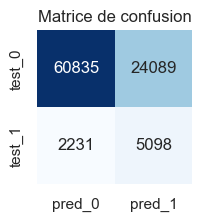


Score métier sur le jeu de test avec les meilleurs hyper-paramètres :
46399
              precision    recall  f1-score   support

         0.0       0.96      0.72      0.82     84924
         1.0       0.17      0.70      0.28      7329

    accuracy                           0.71     92253
   macro avg       0.57      0.71      0.55     92253
weighted avg       0.90      0.71      0.78     92253


AUC sur le jeu d'entraînement complet


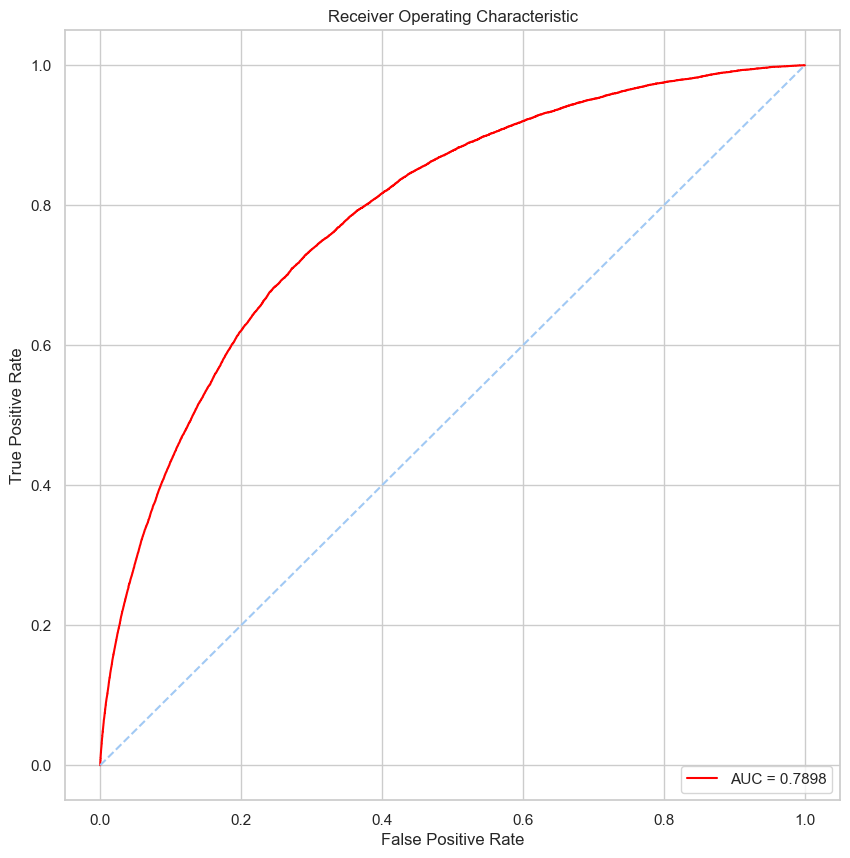


AUC sur le jeu de test


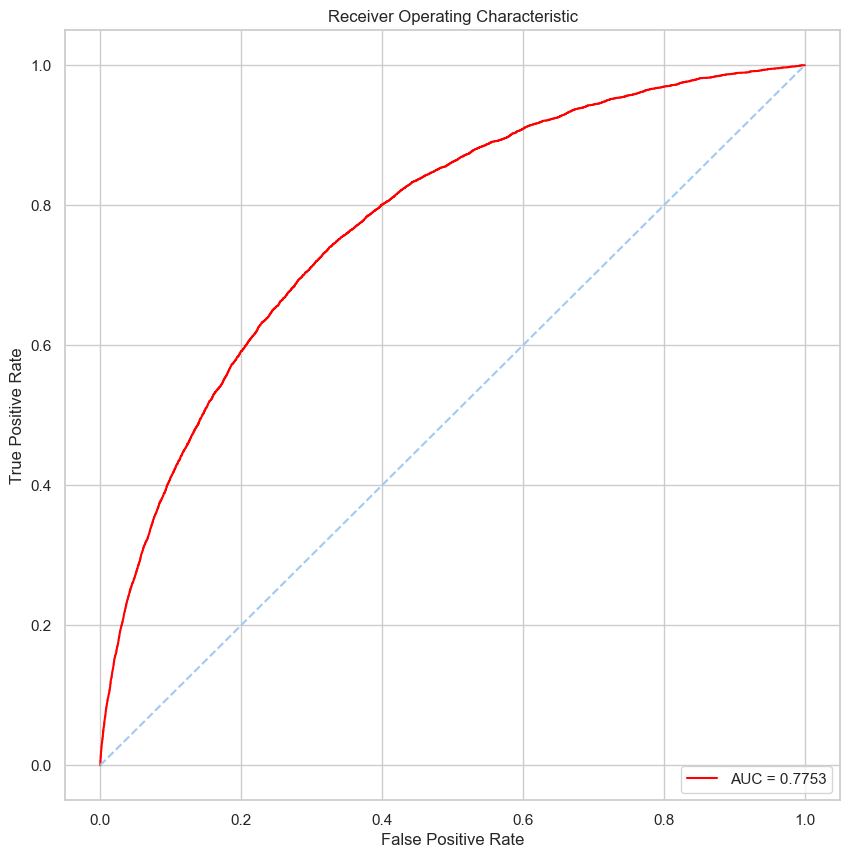

------------------------------------------------------------------------------------------
LightGBM


C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [468 718 723 742] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Résultats de la validation croisée :
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -82415.00 (+/-2450.46) pour {'lgbmclassifier__colsample_bytree': 0.1, 'lgbmclassifier__max_depth': 2, 'lgbmclassifier__n_estimators': 10}
Score métier moyen sur les folds du jeu de test dans la CV = -41815.33 (+/-1207.17) pour {'lgbmclassifier__colsample_bytree': 0.1, 'lgbmclassifier__max_depth': 2, 'lgbmclassifier__n_estimators': 10}
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -70844.33 (+/-580.76) pour {'lgbmclassifier__colsample_bytree': 0.1, 'lgbmclassifier__max_depth': 2, 'lgbmclassifier__n_estimators': 200}
Score métier moyen sur les folds du jeu de test dans la CV = -36410.33 (+/-610.89) pour {'lgbmclassifier__colsample_bytree': 0.1, 'lgbmclassifier__max_depth': 2, 'lgbmclassifier__n_estimators': 200}
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -75173.33 (+/-579.43) pour {'lgbmclassifier__colsample_bytree': 0.1, 'lgbmclassifier

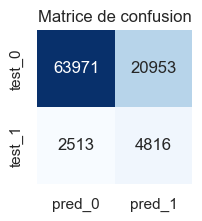


Score métier sur le jeu de test avec les meilleurs hyper-paramètres :
46083
              precision    recall  f1-score   support

         0.0       0.96      0.75      0.85     84924
         1.0       0.19      0.66      0.29      7329

    accuracy                           0.75     92253
   macro avg       0.57      0.71      0.57     92253
weighted avg       0.90      0.75      0.80     92253


AUC sur le jeu d'entraînement complet


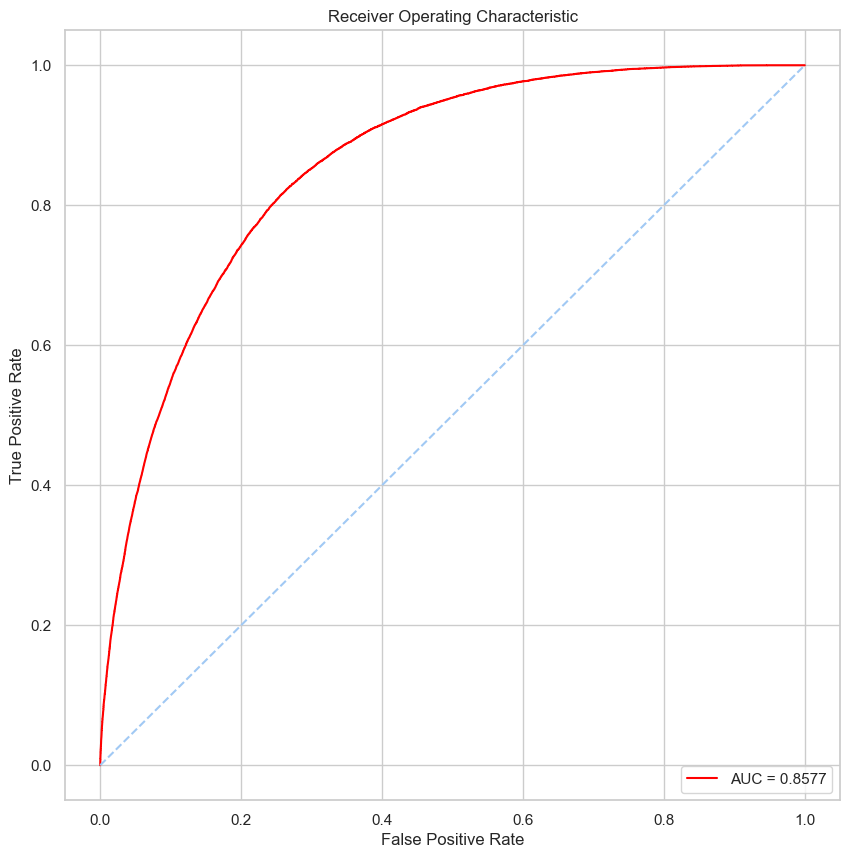


AUC sur le jeu de test


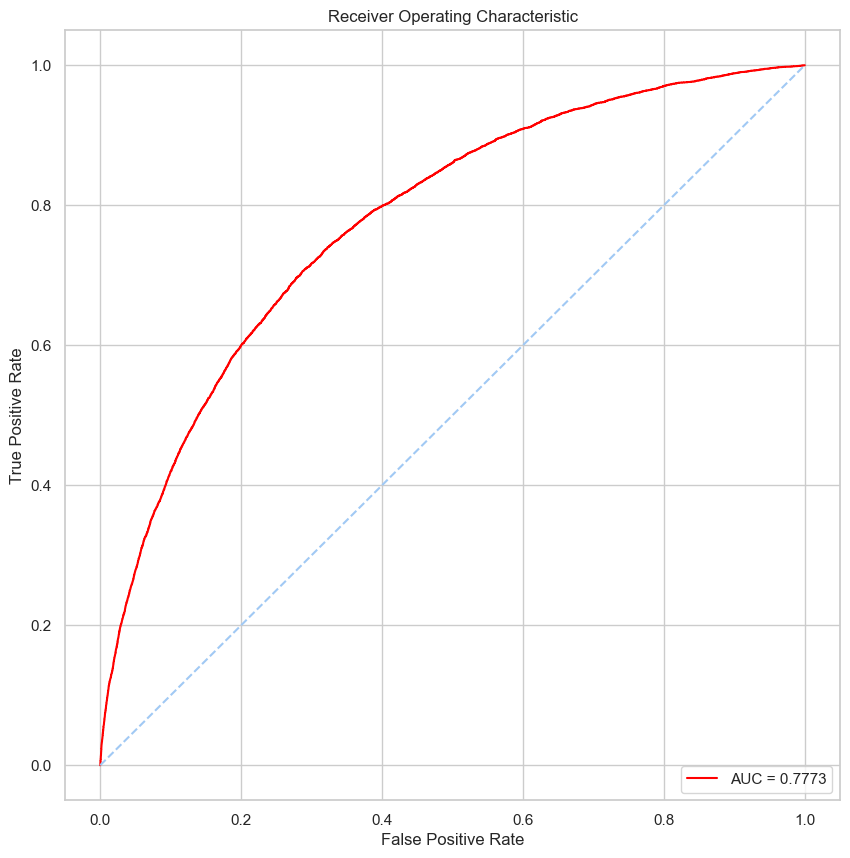

In [38]:
for nom, modele in dict_of_models.items():
    print('-'*90)
    print(nom)
    optimisation(modele, nom)

C'est finalement le modèle **LightGBM** qui obient les meilleurs scores, qu'il s'agisse de l'AUC sur le jeu de test et surtout du score métier.

C'est donc c'est algorithme que je vais tenter d'optimiser pour gagner encore plus de performance, à l'aide de **RandomizedSearchCV**.
## Optimisation poussée de l'algorithme LGBMClassifier
Je réalise un tracking des expériences avec **MLFlow** afin d'affiner le modèle au fil de l'eau sur plusieurs jours si besoin en m'appuyant sur les résultats passés avec une méthode en entonnoir.
### Hyper-paramètres et leur *range* à tester

In [39]:
hyper_params = {'pipeline__selectkbest__k': np.arange(541, 543),
                'lgbmclassifier__n_estimators': np.linspace(2013, 2015, 20, dtype='int32'),
                'lgbmclassifier__learning_rate': np.linspace(0.023, 0.025, 20),
                'lgbmclassifier__num_leaves': np.arange(58, 60),
                'lgbmclassifier__max_depth': np.arange(2, 4)
                }

### Création d'une expérience MLFlow

In [40]:
# experiment_id = mlflow.create_experiment("Optimisation du modèle final")

C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [468 718 723 742] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Yann\.conda\envs\P7\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


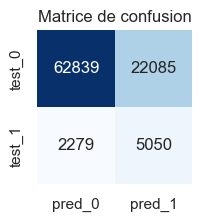


Score métier sur le jeu de test = 44875 
(Le meilleur est le plus bas)

              precision    recall  f1-score   support

         0.0       0.97      0.74      0.84     84924
         1.0       0.19      0.69      0.29      7329

    accuracy                           0.74     92253
   macro avg       0.58      0.71      0.57     92253
weighted avg       0.90      0.74      0.79     92253


Résultats de la validation croisée :
Score métier moyen sur les folds du jeu d'entraînement dans la CV = -58763.33 (+/-940.07) pour {'pipeline__selectkbest__k': 541, 'lgbmclassifier__num_leaves': 59, 'lgbmclassifier__n_estimators': 2014, 'lgbmclassifier__max_depth': 3, 'lgbmclassifier__learning_rate': 0.024473684210526318}
Score métier moyen sur les folds du jeu de test dans la CV = -35507.33 (+/-907.39) pour {'pipeline__selectkbest__k': 541, 'lgbmclassifier__num_leaves': 59, 'lgbmclassifier__n_estimators': 2014, 'lgbmclassifier__max_depth': 3, 'lgbmclassifier__learning_rate': 0.0244736842105

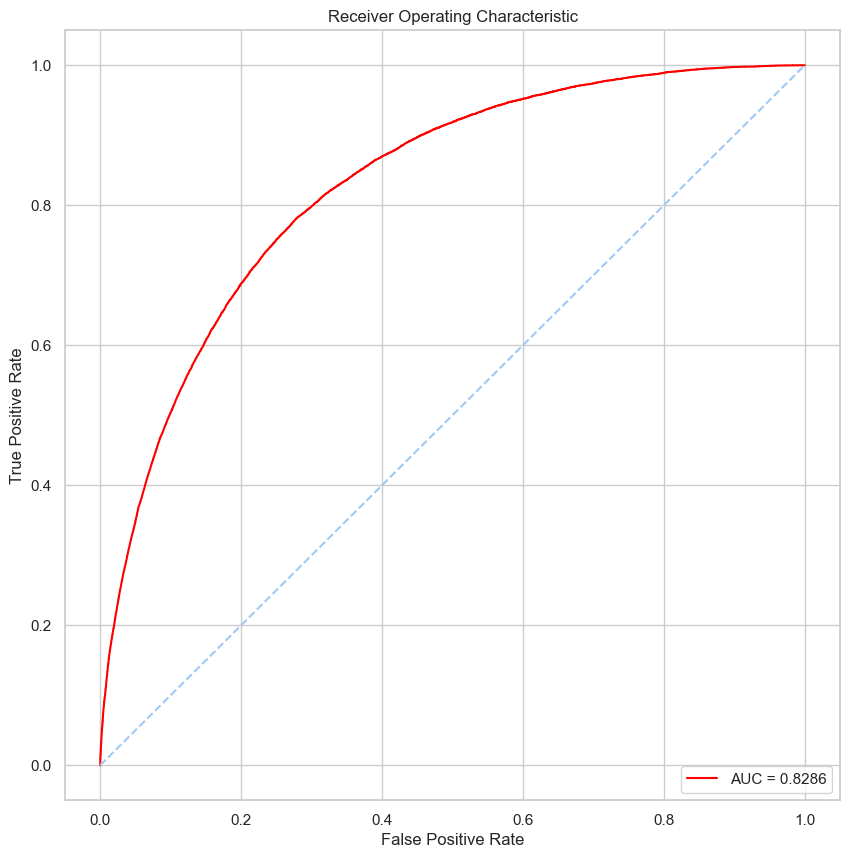


AUC sur le jeu de test :


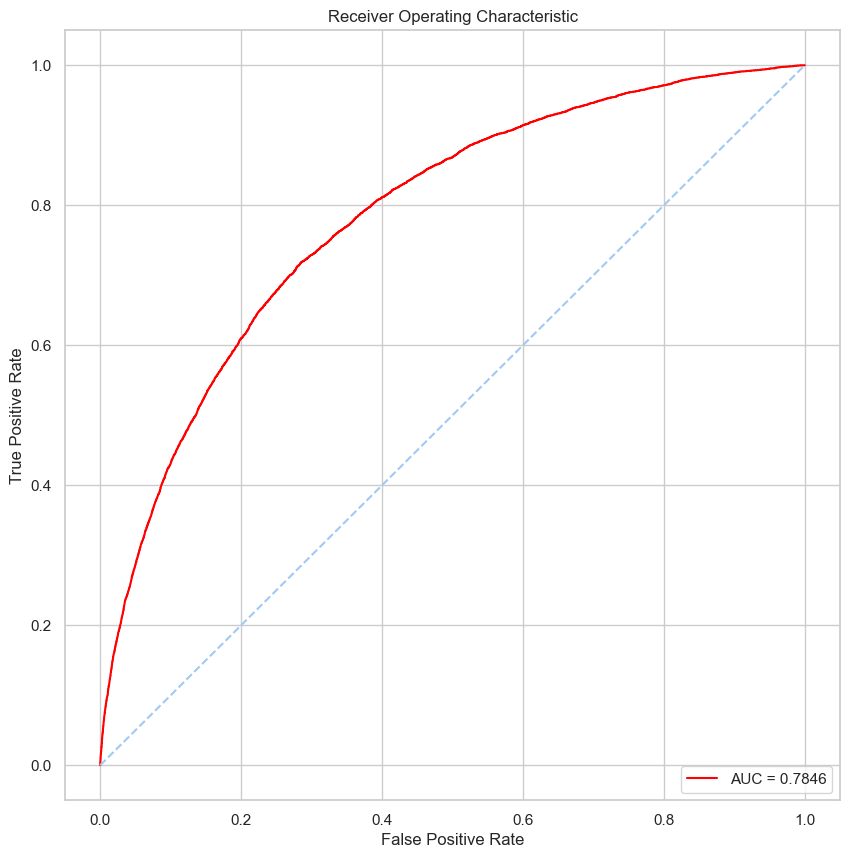

C:\Users\Yann\.conda\envs\P7\lib\site-packages\_distutils_hack\__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")


In [41]:
with mlflow.start_run(experiment_id=838986246537249936):
    
    score_metier = make_scorer(fonction_metier, greater_is_better=False)
    
    grid = RandomizedSearchCV(LightGBM, hyper_params, scoring=score_metier, cv=3,
                              n_iter=40, n_jobs=-1, return_train_score=True)
    
    grid.fit(X_train, y_train)
    y_pred = grid.best_estimator_.predict(X_test)
    y_pred_proba_train = grid.best_estimator_.predict_proba(X_train)[:,1]
    y_pred_proba_test = grid.best_estimator_.predict_proba(X_test)[:,1]
    
    matrice_confusion = confusion(y_test, y_pred)
    score_metier = fonction_metier(y_test, y_pred)
    print("\nScore métier sur le jeu de test =", score_metier, "\n(Le meilleur est le plus bas)")
    print()
    print(classification_report(y_test, y_pred))
    
    print("\nRésultats de la validation croisée :")    
    for mean_train_train, std_train_train, params_train_train, mean_test_train, std_test_train, params_test_train in zip(
        grid.cv_results_['mean_train_score'], # score moyen sur train de validation
        grid.cv_results_['std_train_score'],  # écart-type du score sur train de validation
        grid.cv_results_['params'],           # valeur de l'hyperparamètre
        grid.cv_results_['mean_test_score'], # score moyen sur fold de test de validation
        grid.cv_results_['std_test_score'],  # écart-type du score sur fold de test de validation
        grid.cv_results_['params']           # valeur de l'hyperparamètre
        ):
        print("Score métier moyen sur les folds du jeu d'entraînement dans la CV = {:.2f} (+/-{:.02f}) pour {}".format(
            mean_train_train,
            std_train_train*2,
            params_train_train
        ))
        print("Score métier moyen sur les folds du jeu de test dans la CV = {:.2f} (+/-{:.02f}) pour {}".format(
            mean_test_train,
            std_test_train*2,
            params_test_train
        ))
    
    print('\nMeilleurs hyper-paramètres :',grid.best_params_)
    print("\nAUC sur le jeu d'entraînement complet :")
    roc_auc_train = roc_auc(y_train, y_pred_proba_train)
    print("\nAUC sur le jeu de test :")
    roc_auc_test = roc_auc(y_test, y_pred_proba_test)
        
    for param, value in grid.best_params_.items():
        mlflow.log_param(param, value)
    
    mlflow.log_metric("Score métier Validation Train", mean_train_train)
    mlflow.log_metric("Score métier Validation Test", mean_test_train)
    mlflow.log_metric("ROC AUC Validation Train", roc_auc_train)
    mlflow.log_metric("ROC AUC Validation Test", roc_auc_test)
    mlflow.log_metric("Score métier Test", score_metier)
    
    mlflow.sklearn.log_model(grid.best_estimator_, "Modèle")

## Optimisation ultime avec le seuil de décision
A présent, la liste des runs de l'expérience - visible avec **MLFlow UI** - fournit le meilleur modèle et ses hyperparamètres.

Je le charge afin de déterminer le seuil de décision qui fournira le meilleur score métier.

In [34]:
perfect_model = mlflow.sklearn.load_model('runs:/371e61e24a1c49ba9d4ff035f47ea6c5/Modèle')

In [35]:
precision, recall, threshold = precision_recall_curve(y_test, perfect_model.predict_proba(X_test)[:,1])

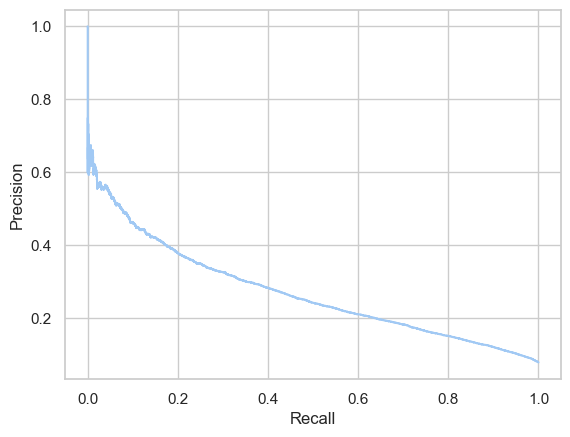

In [36]:
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()

In [37]:
def model_final(model, X, threshold=0.5):
    """Renvoie la classe en fonction de la probabilité de target et du seuil de décision"""
    
    return model.predict_proba(X)[:,1]  >= threshold

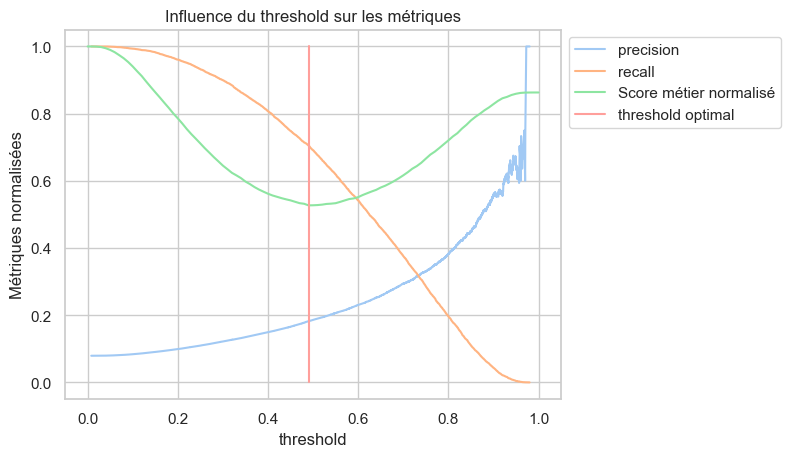

Score métier optimal de 44759 (0.53 normalisé) pour un threshold de 0.49


In [38]:
thres=[]
scor_met=[]
for th in np.linspace(0, 1, 101):
    y_pred = model_final(perfect_model, X_test, threshold=th)
    s_m = fonction_metier(y_test, y_pred)
    thres.append(th)
    scor_met.append(s_m)
    
plt.plot(threshold, precision[:-1], label='precision')
plt.plot(threshold, recall[:-1], label='recall')
tab = pd.DataFrame({'seuil': thres, 'score métier': scor_met})
plt.plot(thres, tab['score métier']/tab['score métier'].max(), label='Score métier normalisé')
seuil_sc_min = tab['seuil'].loc[tab['score métier'] == tab['score métier'].min()]
plt.plot((seuil_sc_min, seuil_sc_min), (0, 1), label='threshold optimal')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xlabel('threshold')
plt.ylabel('Métriques normalisées')
plt.title('Influence du threshold sur les métriques')
plt.show()
print("Score métier optimal de {} ({:.2f} normalisé) pour un threshold de {:.2f}".format(
            tab['score métier'].min(),
            tab['score métier'].min()/tab['score métier'].max(),
            tab['seuil'][tab['score métier'].argmin()]))

Le score métier ci-dessus est déterminé en faisant varier le threshold par pas de 0,01.

Il est possible d'affiner pour trouver le threshold le plus précis donnant un score métier le plus bas possible.

In [39]:
thres=[]
scor_met=[]
for th in np.linspace(0.490974, 0.49098, 5):
    y_pred = model_final(perfect_model, X_test, threshold=th)
    s_m = fonction_metier(y_test, y_pred)
    thres.append(th)
    scor_met.append(s_m)
    
tab = pd.DataFrame({'seuil': thres, 'score métier': scor_met})
best_score_metier = tab['score métier'][2]
best_treshold = tab['seuil'][2]
print("Score métier le plus bas = {}\npour threshold = {:.6f}".format(
            best_score_metier,
            best_treshold))
tab

Score métier le plus bas = 44718
pour threshold = 0.490977


,seuil,score métier
0,0.490974,44719
1,0.490976,44718
2,0.490977,44718
3,0.490979,44718
4,0.490980,44728


## Résultats globaux du modèle final

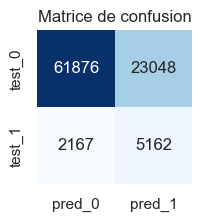


Score métier = 44718 
(Le meilleur est le plus bas)

              precision    recall  f1-score   support

         0.0       0.97      0.73      0.83     84924
         1.0       0.18      0.70      0.29      7329

    accuracy                           0.73     92253
   macro avg       0.57      0.72      0.56     92253
weighted avg       0.90      0.73      0.79     92253



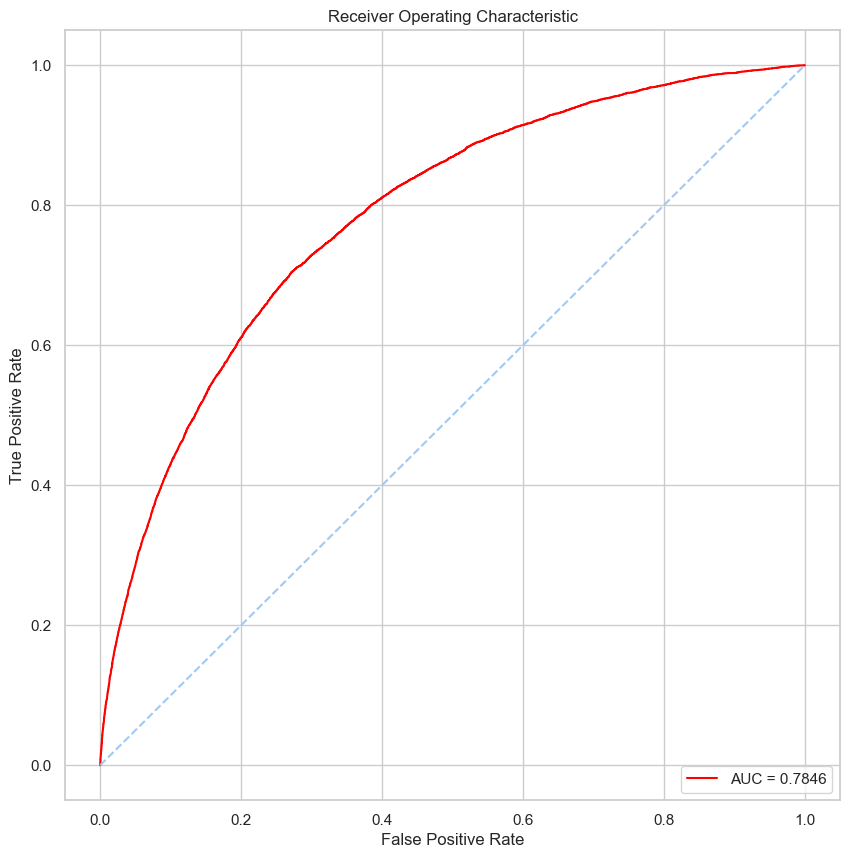

0.7846017983997751

In [40]:
y_pred = model_final(perfect_model, X_test, threshold=best_treshold)
y_pred_proba = perfect_model.predict_proba(X_test)[:,1]
matrice_confusion = confusion(y_test, y_pred)
score_metier = fonction_metier(y_test, y_pred)
print("\nScore métier =", score_metier, "\n(Le meilleur est le plus bas)")
print()
print(classification_report(y_test, y_pred))
roc_auc(y_test, y_pred_proba)

## Features importance

In [41]:
f = lambda x: perfect_model.predict_proba(x)[:,1]
med = X_train.median().values.reshape((1,X_train.shape[1]))

explainer = shap.Explainer(f, med)
shap_values = explainer(X_test.iloc[0:1000,:], max_evals=1595)

X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted

X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted

X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted

X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted

Permutation explainer:  18%|█▊        | 177/1000 [00:11<00:38, 21.25it/s]X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
Permutation explainer:  18%|█▊        | 180/1000 [00:11<00:39, 20.96it/s]X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X do

...

Permutation explainer:  83%|████████▎ | 829/1000 [00:41<00:08, 19.15it/s]X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
Permutation explainer:  83%|████████▎ | 832/1000 [00:41<00:08, 20.15it/s]X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X do

Permutation explainer:  87%|████████▋ | 866/1000 [00:43<00:06, 19.31it/s]X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
Permutation explainer:  87%|████████▋ | 869/1000 [00:43<00:06, 20.61it/s]X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X do

Permutation explainer:  90%|█████████ | 903/1000 [00:44<00:04, 22.93it/s]X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
Permutation explainer:  91%|█████████ | 906/1000 [00:45<00:04, 22.91it/s]X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X do

X does not have valid feature names, but SimpleImputer was fitted with feature names
Permutation explainer:  94%|█████████▍| 942/1000 [00:46<00:02, 22.76it/s]X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
Permutation explainer:  94%|█████████▍| 945/1000 [00:46<00:02, 22.13it/s]X does not have valid feature names, but SimpleImputer was fitted with feature names
X do

Permutation explainer:  98%|█████████▊| 978/1000 [00:48<00:01, 21.20it/s]X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
Permutation explainer:  98%|█████████▊| 981/1000 [00:48<00:00, 21.78it/s]X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X does not have valid feature names, but SimpleImputer was fitted with feature names
X do

In [53]:
len(shap_values[0])

761

In [60]:
len(shap_values[50])

761

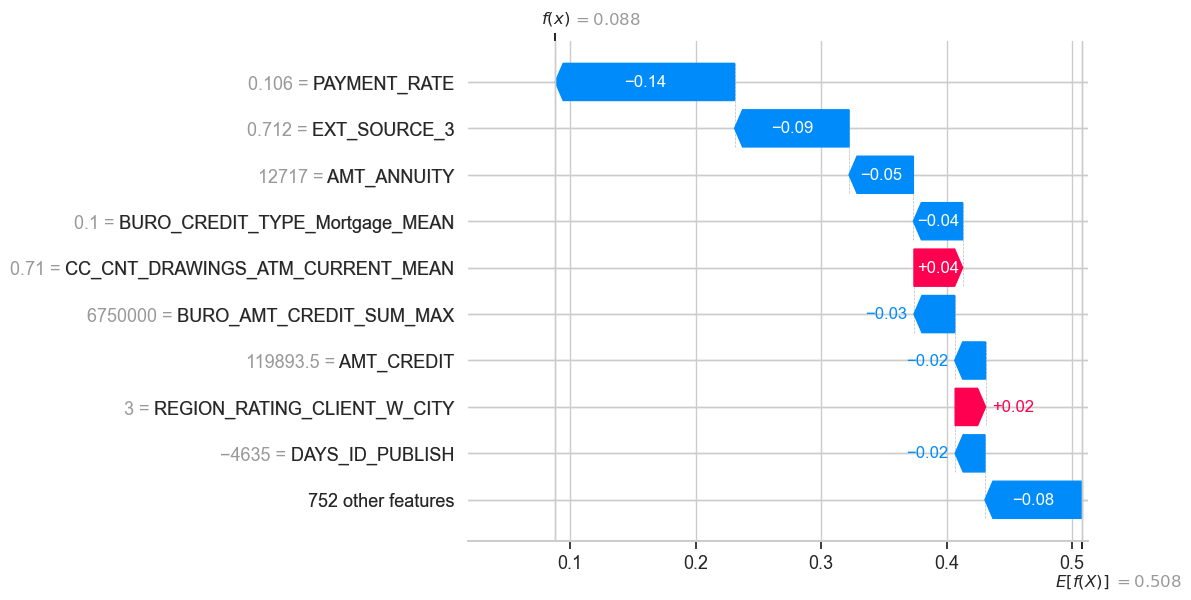

In [56]:
shap.plots.waterfall(shap_values[9], max_display=10)

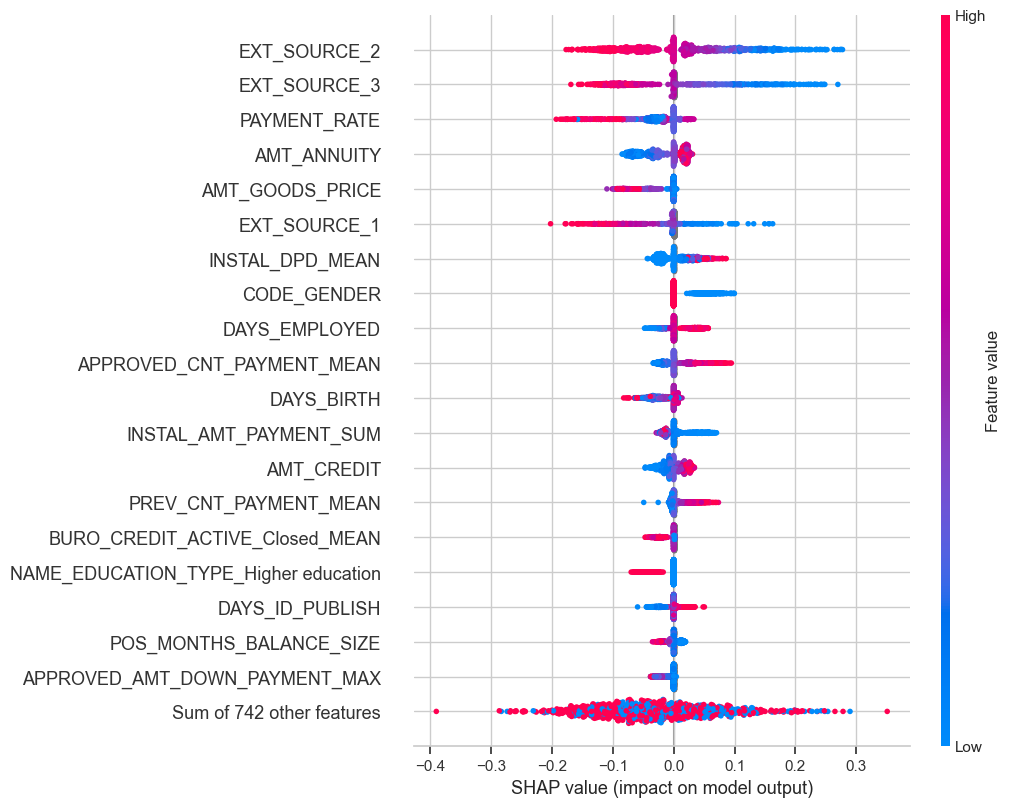

In [62]:
shap.plots.beeswarm(shap_values, max_display=20)

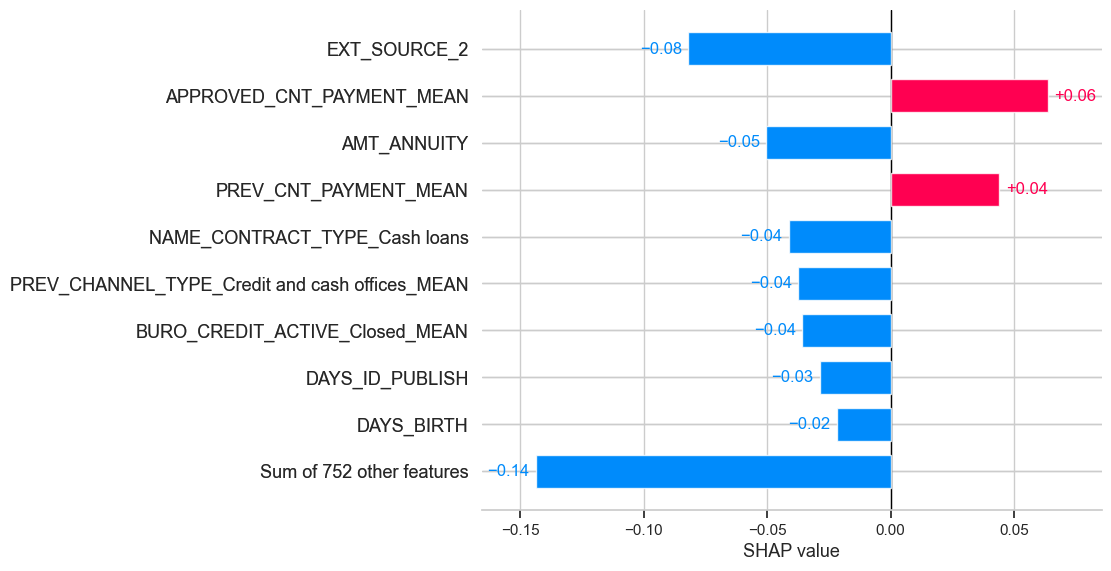

In [50]:
shap.plots.bar(shap_values[1], max_display=10)

## Pipeline de prédiction
### Apprentissage de la pipeline sur les données d'apprentissage

In [44]:
perfect_model.fit(X_train, y_train)

Features [468 718 723 742] are constant.
invalid value encountered in divide


Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('simpleimputer',
                                  SimpleImputer(strategy='median')),
                                 ('selectkbest', SelectKBest(k=542))])),
                ('lgbmclassifier',
                 LGBMClassifier(class_weight='balanced',
                                learning_rate=0.02363157894736842, max_depth=3,
                                n_estimators=2014, num_leaves=59,
                                random_state=39))])

### Calcul du score métier sur la base de test

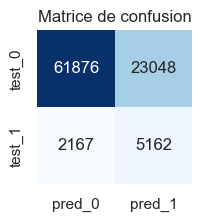


Score métier = 44718 
(Le meilleur est le plus bas)

              precision    recall  f1-score   support

         0.0       0.97      0.73      0.83     84924
         1.0       0.18      0.70      0.29      7329

    accuracy                           0.73     92253
   macro avg       0.57      0.72      0.56     92253
weighted avg       0.90      0.73      0.79     92253



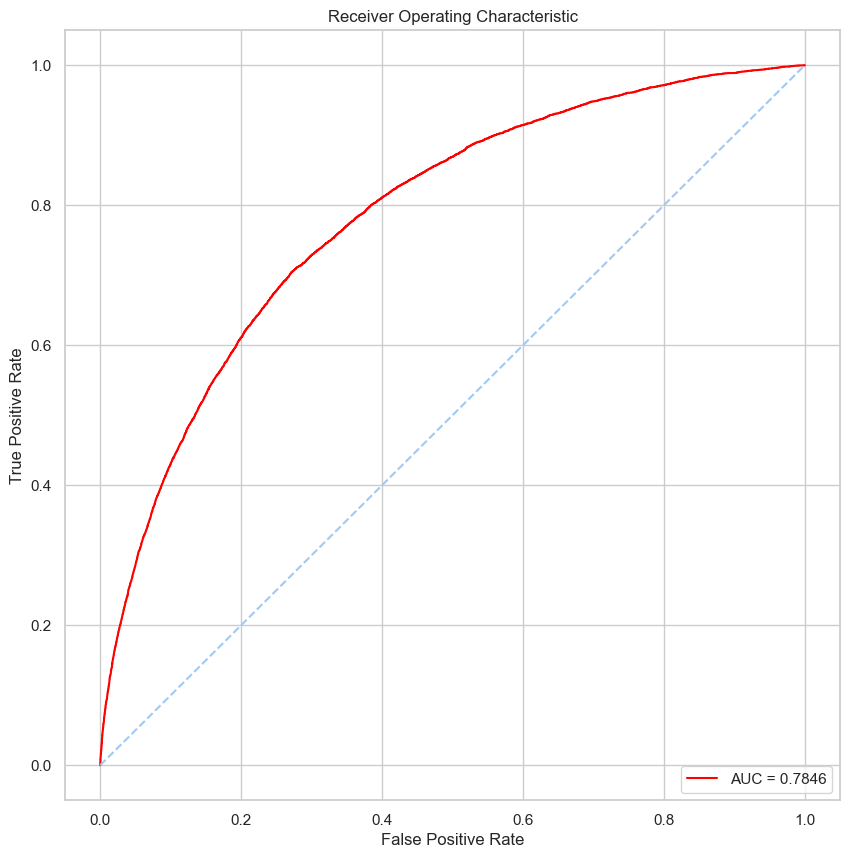

0.7846017983997751

In [45]:
y_pred = model_final(perfect_model, X_test, threshold=best_treshold)
y_pred_proba = perfect_model.predict_proba(X_test)[:,1]
matrice_confusion = confusion(y_test, y_pred)
score_metier = fonction_metier(y_test, y_pred)
print("\nScore métier =", score_metier, "\n(Le meilleur est le plus bas)")
print()
print(classification_report(y_test, y_pred))
roc_auc(y_test, y_pred_proba)

## Sérialisation de la pipeline

In [46]:
joblib.dump(perfect_model, 'pipeline_lgbm.joblib')

['pipeline_lgbm.joblib']

## Déploiement d'un modèle sklearn avec MLflow
### Signature d'un modèle

In [47]:
signature = infer_signature(X_train, y_train)

Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.


### Sauvegarde du modèle sklearn

In [64]:
mlflow.sklearn.save_model(perfect_model, 'mlflow_model', signature=signature)

Setuptools is replacing distutils.
